<a href="https://colab.research.google.com/github/Elvis-Kayonga/Data-Preprocessing-Formative2-ML-GROUP9/blob/main/notebooks/voice_recognition_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q voice_files.zip

# Audio Recognition System (Speaker Identification)

## Assignment: Audio Data Preprocessing

This notebook demonstrates:
- Audio data loading
- Feature extraction using MFCC
- Dataset creation
- Saving features to CSV
- Training a machine learning model for speaker recognition

The goal is to convert raw audio into numerical features that a machine learning model can understand.

In [ ]:
#Install libraries
import librosa
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, log_loss, f1_score
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
#access dataset
audio_folder = "voice_files"
files = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]
print(f"Found {len(files)} audio files:")
print(files)

Found 8 audio files:
['samuel-approve.wav', 'kayonga-confirm.wav', 'sharif-approve.wav', 'kayonga-approve.wav', 'paulette-confirm.wav', 'samuel-confirm.wav', 'sharif-confirm.wav', 'paulette-approve.wav']


## Dataset Preparation and cleaning pipeline

Each audio file is named using the format:

username_something.wav

1.we trim the audio files

2.we normalise them

3.we augment all every audio files

4.we plot the waveform and spectrogram for each file

5.we augment all every audio files

6.We extract:
- 13 MFCC features
- Spectral rolloff
- Energy

These features represent the voice characteristics of each speaker.

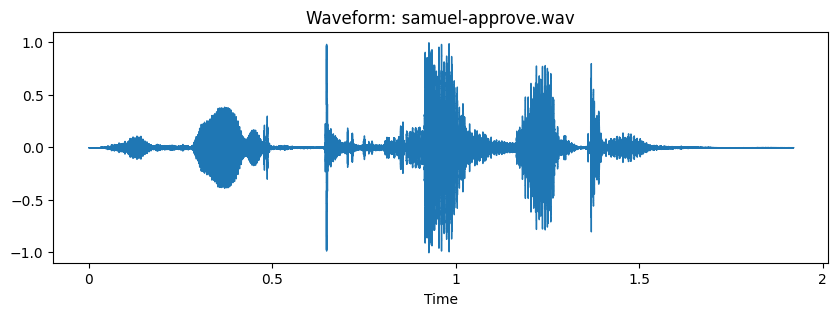

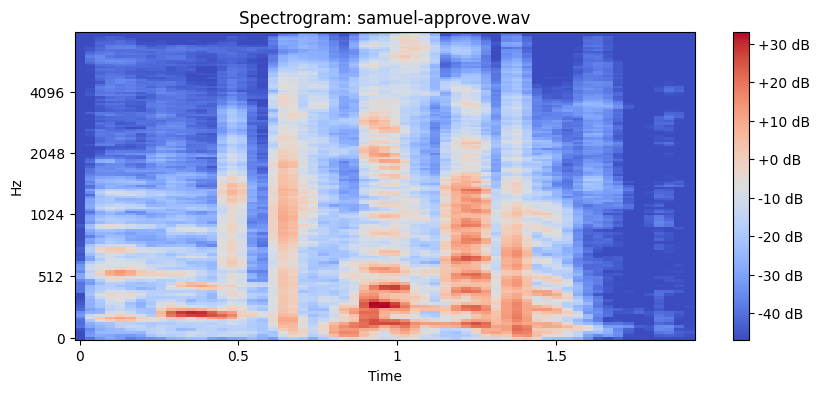

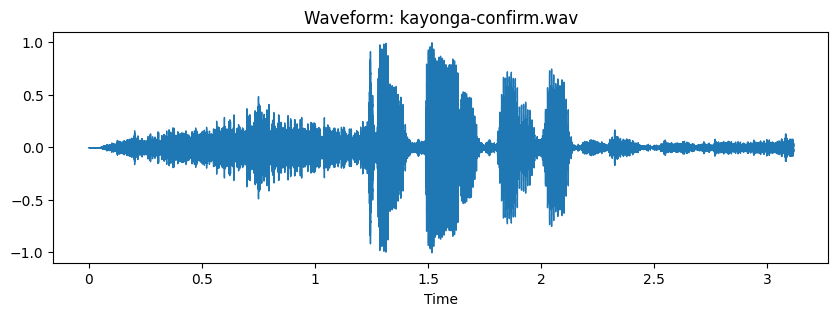

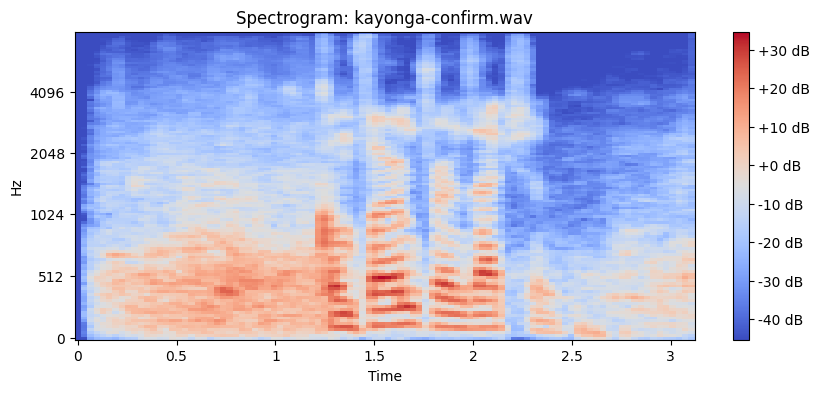

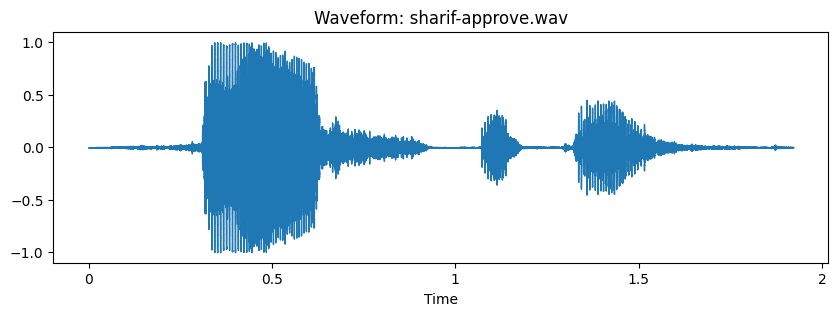

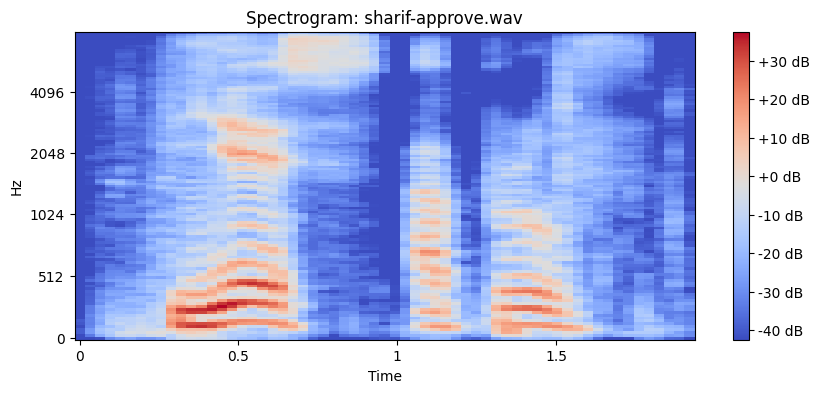

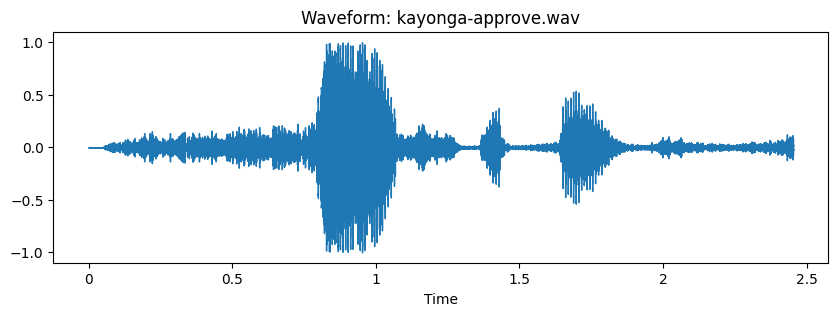

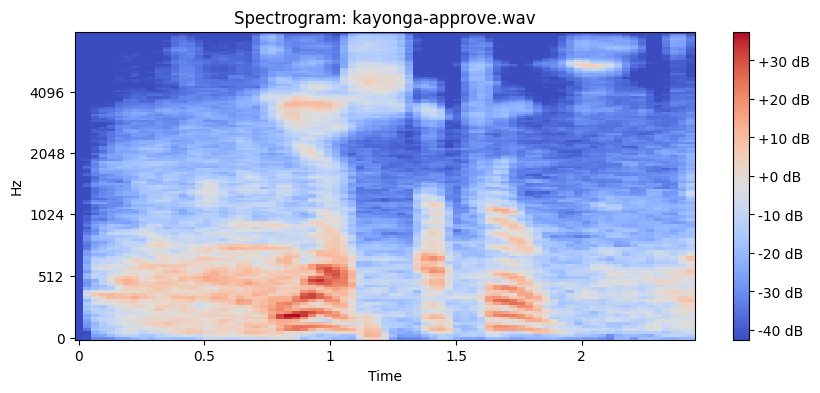

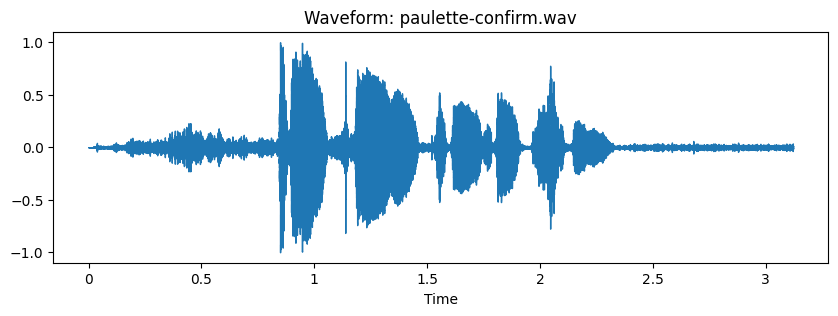

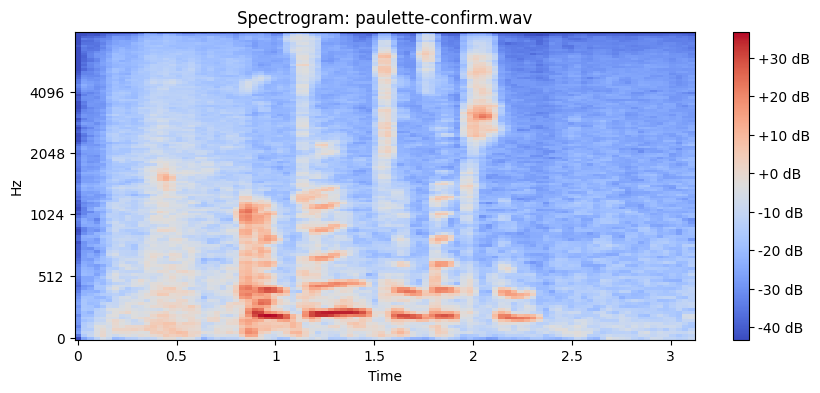

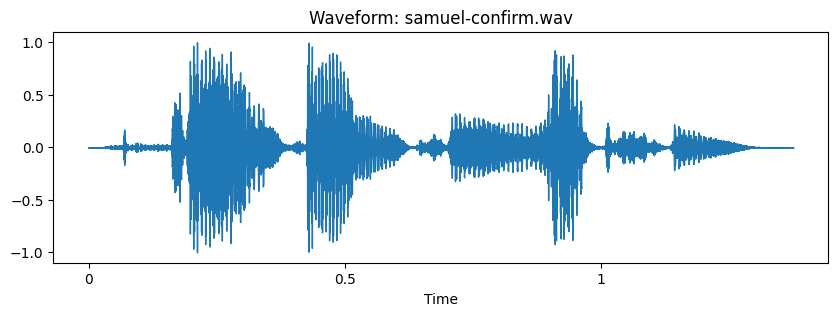

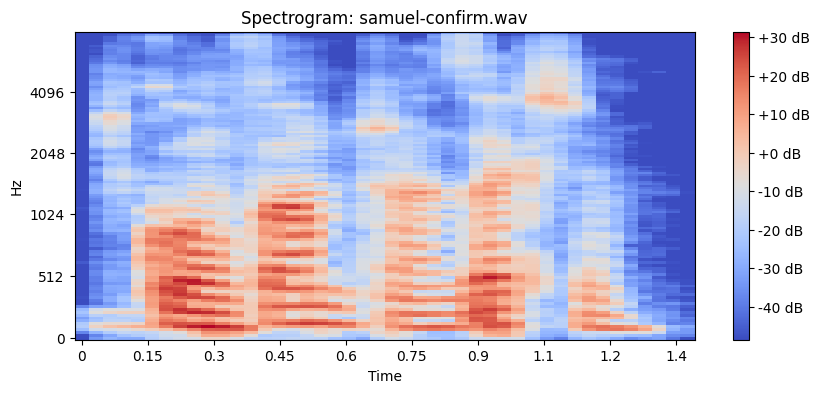

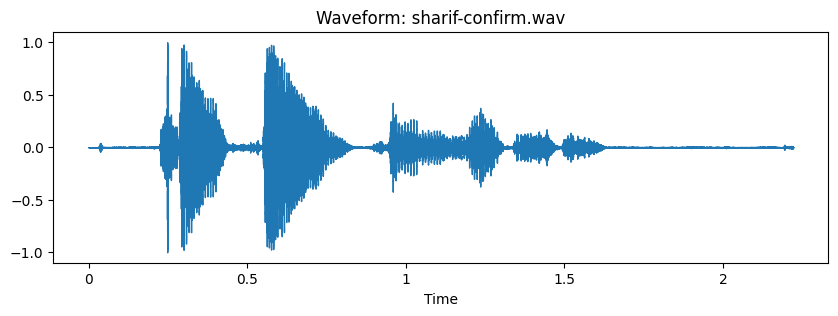

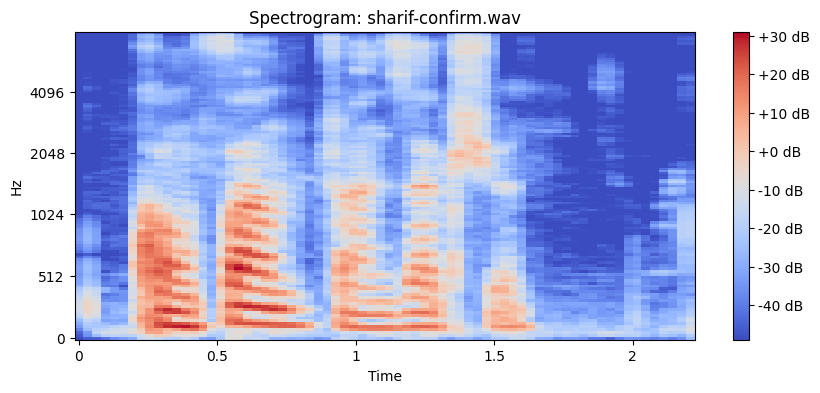

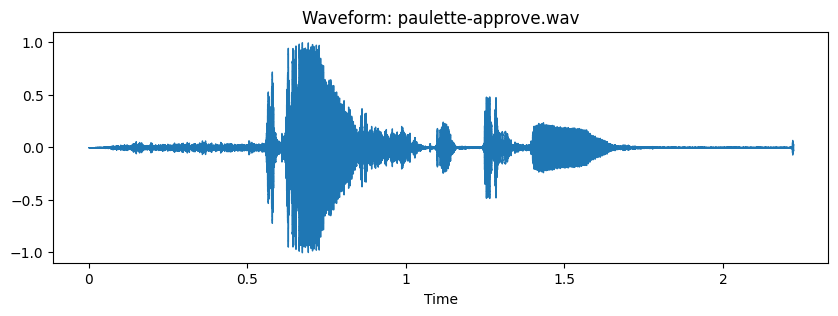

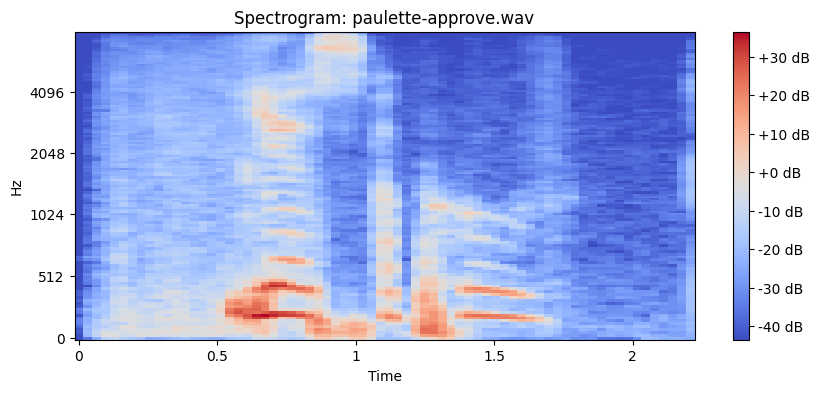

In [ ]:
#Lists to store features and labels
features = []
labels = []

#loop through all audio files
for file in files:
  file_path = os.path.join(audio_folder, file)
  user = file.split('-')[0]
  y, sr = librosa.load(file_path, sr=16000)

  #audio cleaning
  y, _ = librosa.effects.trim(y)
  y = librosa.util.normalize(y)

  #visualisations
  plt.figure(figsize=(10,3))
  librosa.display.waveshow(y, sr=sr)
  plt.title(f"Waveform: {file}")
  plt.show()

  S = librosa.feature.melspectrogram(y=y, sr=sr)

  plt.figure(figsize=(10,4))
  librosa.display.specshow(librosa.power_to_db(S), sr=sr, x_axis='time', y_axis='mel')
  plt.title(f"Spectrogram: {file}")
  plt.colorbar(format='%+2.0f dB')
  plt.show()

    # Pitch shift
  y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

    # Time stretch
  y_stretch = librosa.effects.time_stretch(y, rate=1.2)

    # Add noise
  noise = np.random.randn(len(y))
  y_noise = y + 0.005 * noise

  augmented_signals = [y, y_pitch, y_stretch, y_noise]


  for signal in augmented_signals:

      mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
      mfcc_mean = np.mean(mfcc.T, axis=0)

        # Additional required features
      rolloff = np.mean(librosa.feature.spectral_rolloff(y=signal, sr=sr))
      energy = np.mean(signal**2)

      feature_vector = np.append(mfcc_mean, [rolloff, energy])

      features.append(feature_vector)
      labels.append(user)

#Converting the features and label into pandas dataframe

In [ ]:
X = np.array(features)
y = np.array(labels)

df = pd.DataFrame(X)
df['user'] = y

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,user
0,-271.775970,92.671173,-1.351117,9.075889,-3.170000,10.203656,-1.232884,-4.206328,-6.876666,-3.472046,-2.598192,0.424562,-7.577137,3094.518443,0.016370,samuel
1,-275.008270,88.692085,-6.870210,6.587543,-1.534026,6.825873,-7.978793,-7.102568,-6.023678,-2.821397,-1.610474,-5.626621,-6.603024,3278.560451,0.007710,samuel
2,-278.271454,95.808296,-4.737083,9.458437,-2.449935,8.509868,-3.024519,-5.301500,-7.142269,-4.570948,-3.076958,-0.692022,-9.080901,3008.884804,0.010157,samuel
3,-194.567470,57.143195,8.417430,5.397926,0.134921,4.071523,-0.334896,-3.000121,-4.769136,-5.383320,-2.229798,-1.655335,-5.000257,4821.593238,0.016406,samuel
4,-203.462784,144.726089,-0.554127,28.893513,-13.392103,-13.847366,-10.420803,-13.329345,-8.025827,3.666438,-5.326194,-2.850114,-4.956906,1950.175383,0.020128,kayonga


In [ ]:
# Save features CSV locally (also to extracted_datasets/ for the repo)
os.makedirs('../extracted_datasets', exist_ok=True)
df.to_csv('../extracted_datasets/audio_features.csv', index=False)
df.to_csv('audio_features.csv', index=False)
print(f"audio_features.csv saved. Shape: {df.shape}")

audio_features.csv saved. Shape: (32, 16)


#Splitting the data into train and test

In [ ]:
# Separate features and labels
X = df.drop("user", axis=1)
y = df["user"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, y_train.shape)
print("Data split completed.")

(25, 15) (25,)
Data split completed.


#Training the voice recognition model using Random Forest Algorithm

In [ ]:
# Create model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

#cross validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("CV Mean Accuracy:", cv_scores.mean())

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

CV Mean Accuracy: 0.9199999999999999
Model training completed.


#Evaluating the model's performance on test dataset using accuacy, log loss, f1_score and classification report metrics

In [ ]:
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Encode labels for log_loss
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
loss = log_loss(y_test_encoded, y_prob)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"F1-Score : {f1:.4f}")
print(f"Log Loss : {loss:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 85.71%
F1-Score : 0.8571
Log Loss : 0.4283

Classification Report:
              precision    recall  f1-score   support

     kayonga       1.00      1.00      1.00         2
    paulette       0.50      1.00      0.67         1
      samuel       1.00      0.50      0.67         2
      sharif       1.00      1.00      1.00         2

    accuracy                           0.86         7
   macro avg       0.88      0.88      0.83         7
weighted avg       0.93      0.86      0.86         7



In [ ]:
# Save the model
joblib.dump(model, 'speaker_model.pkl')
print(f"Model saved to speaker_model.pkl")

Model saved to speaker_model.pkl
